# Detuned noisy GPG recovery sweep

This notebook shows the current detuned noisy-GPG cooperativity plot, including no-recovery reference lines for the same exact global symmetric amplitude-damping channel. It also provides a compact multiprocessing launcher for high-budget polishing of a selected cooperativity point. The launcher calls `python/scripts/parallel_noisy_gpg_search.py`, which keeps the cache safe by letting workers write candidate files while only the parent process accepts improvements.


Running:
python <repo-root>/python/scripts/parallel_noisy_gpg_search.py --p 0.0005 --c 1000000.0 --workers 4 --max-attempts 4 --restarts 14 --maxiter 3000 --extra-pulses 0 --base-seed 6100000 --no-notebook-preview
This launches one four-core batch; interrupting is safe between accepted updates.

Backup: <repo-root>/datas/noisy_gpgs_pulses/cache/detuned_usual_gpg_p5e-4_p1e-3_Csweep.before_parallel_search_20260526_110234.pkl
No target window configured for C=1e+06.

Launching batch of 4 attempts from current best 1.817435e-03
Attempt 2 seed=6320000 inf=2.071760e-03 max_state=1.079754e-01 wall=70.8 min
Attempt 3 seed=6420000 inf=2.462518e-03 max_state=1.173059e-01 wall=71.1 min
Attempt 4 seed=6520000 inf=5.540239e-03 max_state=9.352857e-02 wall=71.1 min
Attempt 1 seed=6220000 inf=4.770729e-03 max_state=9.069952e-02 wall=71.2 min
Kept old: best candidate 2.071760e-03 >= old 1.817435e-03
Parallel noisy-GPG search finished.

Running:
python <repo-root>/python/scripts/parallel_noisy_gpg_searc

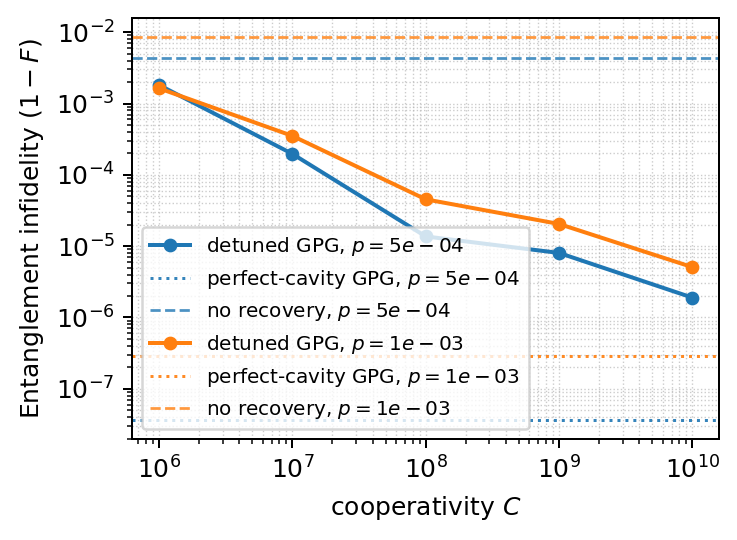

In [10]:
# One four-core polishing batch for the low-C point.
# The script parallelizes independent attempts. With WORKERS=4 and ATTEMPTS_PER_P=4,
# this runs one full four-core batch for each p value at C=10^6.
# Set ATTEMPTS_PER_P=1 if you literally want only one serial attempt per p.

from pathlib import Path
import subprocess
import sys

from IPython.display import Image, display

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "python" / "codes").exists())
script_path = repo_root / "python" / "scripts" / "parallel_noisy_gpg_search.py"
plot_path = repo_root / "plots" / "AD" / "noisy_gpg_implementation" / "detuned_usual_gpg_cooperativity_sweep.png"

# ---------------------------- knobs to edit ----------------------------
P_TARGETS = [5e-4, 1e-3]
C_TARGET = 1e6
WORKERS = 4
ATTEMPTS_PER_P = WORKERS   # One four-core batch per p.
RESTARTS = 14
MAXITER = 3000
EXTRA_PULSES = 0
BASE_SEED = 6_100_000
KEEP_CANDIDATES = False
UPDATE_NOTEBOOK_PREVIEW = False

for run_index, p_target in enumerate(P_TARGETS):
    cmd = [
        sys.executable,
        str(script_path),
        "--p", str(p_target),
        "--c", str(C_TARGET),
        "--workers", str(WORKERS),
        "--max-attempts", str(ATTEMPTS_PER_P),
        "--restarts", str(RESTARTS),
        "--maxiter", str(MAXITER),
        "--extra-pulses", str(EXTRA_PULSES),
        "--base-seed", str(BASE_SEED + run_index * 1_000_000),
    ]
    if KEEP_CANDIDATES:
        cmd += ["--keep-candidates"]
    if not UPDATE_NOTEBOOK_PREVIEW:
        cmd += ["--no-notebook-preview"]

    print("Running:")
    print(" ".join(cmd))
    print("This launches one four-core batch; interrupting is safe between accepted updates.")
    print()
    subprocess.run(cmd, cwd=repo_root, check=True)
    print()

# Show the refreshed plot generated by the script.
display(Image(filename=str(plot_path)))


## Latest noisy-GPG cooperativity plot

Run the cell below to regenerate the plot from the current cache. The plot now includes dashed no-recovery reference lines for each `p` value.

Latest polished `p=5e-4` high-C points:

- `C=1e8`: `1.367446e-05`
- `C=1e9`: `8.023991e-06`
- `C=1e10`: `1.894021e-06`


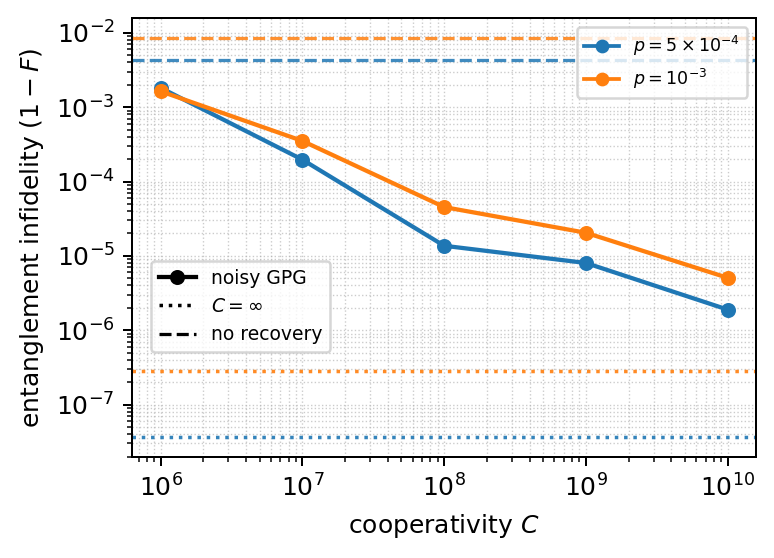

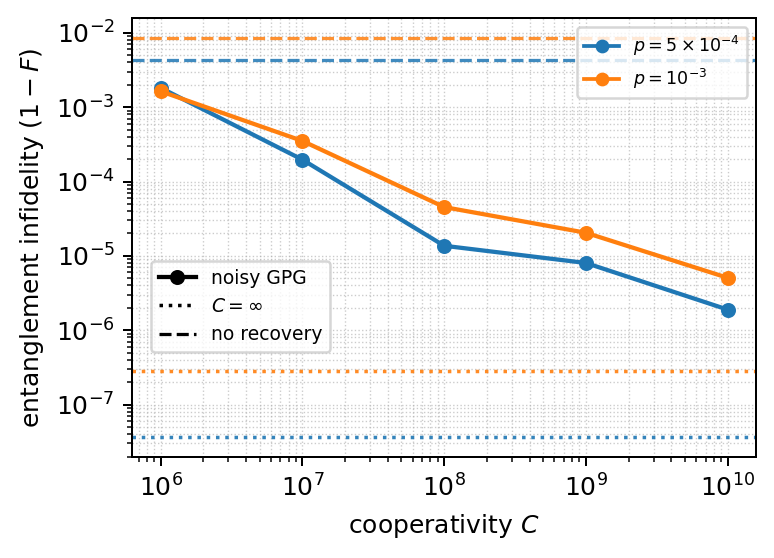

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from IPython.display import display

DATA = Path("../../datas/noisy_gpgs_pulses/detuned_usual_gpg_p5e-4_p1e-3_Csweep_metrics.csv")
OUTDIR = Path("../../plots/AD/noisy_gpg_implementation")
OUTDIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA)

# Edit these knobs freely.
colors = {
    5e-4: "tab:blue",
    1e-3: "tab:orange",
}
marker = "o"
labels = {
    5e-4: r"$p=5\times 10^{-4}$",
    1e-3: r"$p=10^{-3}$",
}

fig, ax = plt.subplots(figsize=(4.4, 3.2), dpi=180)

for p, group in df.groupby("p"):
    p = float(p)
    group = group.sort_values("GPG cooperativity")
    color = colors.get(p, None)
    label = labels.get(p, rf"$p={p:.0e}$")

    ax.loglog(
        group["GPG cooperativity"],
        group["GPG infidelity"],
        marker=marker,
        linestyle="-",
        lw=1.7,
        ms=5,
        color=color,
        label="_nolegend_",
    )

    ax.axhline(
        group["error-free GPG infidelity"].iloc[0],
        color=color,
        linestyle=":",
        lw=1.4,
        alpha=0.9,
        label="_nolegend_",
    )

    ax.axhline(
        group["no recovery infidelity"].iloc[0],
        color=color,
        linestyle="--",
        lw=1.3,
        alpha=0.85,
        label="_nolegend_",
    )

ax.set_xlabel(r"cooperativity $C$")
ax.set_ylabel(r"entanglement infidelity $(1-F)$")
ax.grid(True, which="both", linestyle=":", linewidth=0.55, alpha=0.65)

method_handles = [
    Line2D([0], [0], color="black", marker="o", linestyle="-", lw=1.7, ms=5, label="noisy GPG"),
    Line2D([0], [0], color="black", linestyle=":", lw=1.4, label=r"$C=\infty$"),
    Line2D([0], [0], color="black", linestyle="--", lw=1.3, label="no recovery"),
]
p_handles = [
    Line2D([0], [0], color=colors[p], marker=marker, linestyle="-", lw=1.5, ms=4.5, label=labels[p])
    for p in sorted(labels)
]

method_legend = ax.legend(
    handles=method_handles,
    frameon=True,
    fontsize=7.5,
    loc="lower left",
    bbox_to_anchor=(0.03, 0.24),
    borderaxespad=0.0,
)
ax.add_artist(method_legend)
ax.legend(
    handles=p_handles,
    frameon=True,
    fontsize=7,
    loc="upper right",
)

fig.tight_layout()

pdf_path = OUTDIR / "detuned_usual_gpg_cooperativity_sweep_custom.pdf"
png_path = OUTDIR / "detuned_usual_gpg_cooperativity_sweep_custom.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, bbox_inches="tight")

display(fig)
#print(f"Saved:\n{pdf_path}\n{png_path}")